In [1]:
import tensorflow as tf
import mediapipe as mp
import cv2

print("TensorFlow:", tf.__version__)
print("MediaPipe:", mp.__version__)
print("OpenCV:", cv2.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

TensorFlow: 2.19.0
MediaPipe: 0.10.14
OpenCV: 4.13.0
Has solutions: True


In [2]:
import os
import numpy as np
import time

In [3]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

In [4]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

In [5]:
def draw_landmarks(image, results):

    mp_drawing.draw_landmarks(
        image,
        results.face_landmarks,
        mp_holistic.FACEMESH_CONTOURS
    )

    mp_drawing.draw_landmarks(
        image,
        results.pose_landmarks,
        mp_holistic.POSE_CONNECTIONS
    )

    mp_drawing.draw_landmarks(
        image,
        results.left_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS
    )

    mp_drawing.draw_landmarks(
        image,
        results.right_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS
    )

In [6]:
def draw_styled_landmarks(image,results):
    mp_drawing.draw_landmarks(
        image,
        results.face_landmarks,
        mp_holistic.FACEMESH_CONTOURS,
        mp_drawing.DrawingSpec(color=(80,110,10),thickness=1,circle_radius=1),
        mp_drawing.DrawingSpec(color=(80,256,121),thickness=1,circle_radius=1)
    )

    mp_drawing.draw_landmarks(
        image,
        results.pose_landmarks,
        mp_holistic.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(80,22,10),thickness=2,circle_radius=4),
        mp_drawing.DrawingSpec(color=(80,44,121),thickness=2,circle_radius=2)
    )

    mp_drawing.draw_landmarks(
        image,
        results.left_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(121,22,76),thickness=2,circle_radius=4),
        mp_drawing.DrawingSpec(color=(121,44,250),thickness=2,circle_radius=2)
    )

    mp_drawing.draw_landmarks(
        image,
        results.right_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(245,117,66),thickness=2,circle_radius=1),
        mp_drawing.DrawingSpec(color=(245,66,230),thickness=2,circle_radius=1)
    )

In [7]:
cap = cv2.VideoCapture(0)
with mp_holistic.Holistic(min_detection_confidence=0.5,min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
        ret,frame = cap.read()

        image,results = mediapipe_detection(frame,holistic)
        print(results)

        #Draw landmarks
        draw_styled_landmarks(image,results)
        
        cv2.imshow('OpenCV Feed',image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

C:\Users\GAURAV\anaconda3\envs\signlang2\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [8]:
frame

array([[[238, 243, 246],
        [238, 243, 246],
        [238, 243, 246],
        ...,
        [219, 232, 224],
        [216, 231, 224],
        [217, 232, 225]],

       [[238, 243, 246],
        [238, 243, 246],
        [238, 243, 246],
        ...,
        [219, 232, 224],
        [218, 231, 225],
        [218, 231, 225]],

       [[238, 243, 246],
        [238, 243, 246],
        [238, 243, 246],
        ...,
        [220, 231, 225],
        [220, 231, 225],
        [220, 231, 225]],

       ...,

       [[157, 181, 201],
        [159, 183, 202],
        [160, 183, 201],
        ...,
        [202, 202, 206],
        [200, 199, 205],
        [199, 198, 204]],

       [[141, 163, 181],
        [148, 169, 187],
        [154, 174, 191],
        ...,
        [201, 203, 208],
        [199, 201, 205],
        [198, 200, 204]],

       [[124, 144, 161],
        [134, 153, 170],
        [144, 164, 179],
        ...,
        [202, 205, 210],
        [201, 204, 208],
        [199, 203, 205]]

In [9]:
draw_landmarks(frame,results)


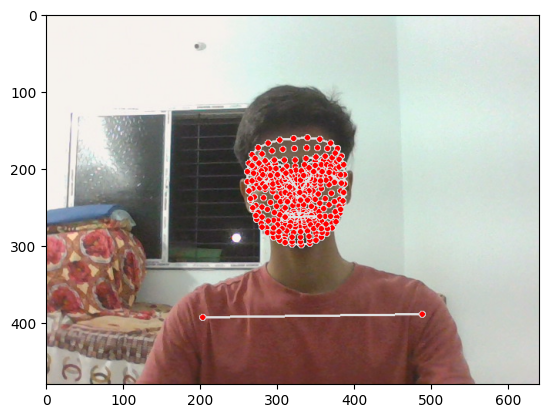

In [10]:
from matplotlib import pyplot as plt

plt.imshow(cv2.cvtColor(frame,cv2.COLOR_BGR2RGB))

EXtract keypoints

In [11]:
results.pose_landmarks.landmark[0]

x: 0.515216708
y: 0.481377512
z: -1.06623602
visibility: 0.999940813

In [12]:
pose = []

for res in results.pose_landmarks.landmark:
    test = np.array([res.x,res.y,res.z,res.visibility])
    pose.append(test)

In [13]:
pose = np.array([[res.x,res.y,res.z,res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)

In [14]:
face = np.array([[res.x,res.y,res.z]
               for res in results.face_landmarks.landmark]).flatten() \
               if results.face_landmarks else np.zeros(1404)

lh = np.array([[res.x,res.y,res.z]
               for res in results.left_hand_landmarks.landmark]).flatten() \
               if results.left_hand_landmarks else np.zeros(21*3)

rh = np.array([[res.x,res.y,res.z]
               for res in results.right_hand_landmarks.landmark]).flatten() \
               if results.right_hand_landmarks else np.zeros(21*3)

In [15]:
def extract_keypoints(results):
    pose = np.array([[res.x,res.y,res.z,res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
    face = np.array([[res.x,res.y,res.z]
               for res in results.face_landmarks.landmark]).flatten() \
               if results.face_landmarks else np.zeros(1404)
    lh = np.array([[res.x,res.y,res.z]
               for res in results.left_hand_landmarks.landmark]).flatten() \
               if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x,res.y,res.z]
               for res in results.right_hand_landmarks.landmark]).flatten() \
               if results.right_hand_landmarks else np.zeros(21*3)

    return np.concatenate([pose, face, lh, rh])

In [16]:
result_test = extract_keypoints(results)[:-10]

In [17]:
np.save('0',result_test)

4. setup folder for data collection

In [18]:
DATA_PATH = os.path.join('MP_Data')

actions = np.array(['hello' , 'thanks', 'iloveyou'])

no_sequences = 30

sequence_length = 30

In [19]:
for action in actions:
    for sequence in range(no_sequences):
        try:
            os.makedirs(os.path.join(DATA_PATH,action,str(sequence)))
        except:
            pass

In [20]:
cap = cv2.VideoCapture(0)
with mp_holistic.Holistic(min_detection_confidence=0.5,min_tracking_confidence=0.5) as holistic:
    #Loop through actions
    for action in actions:

        #Loop through sequence aka videos
        for sequence in range(no_sequences):
            #loop through video length aka sequence length
            for frame_num in range(sequence_length):

                #read feed
                ret,frame = cap.read()
                
                image,results = mediapipe_detection(frame,holistic)
                print(results)
                
                #Draw landmarks
                draw_styled_landmarks(image,results)

                if frame_num == 0:
                    cv2.putText(
                        image,
                        'STARTING COLLECTION',
                        (120, 200),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        1,
                        (0, 255, 0),
                        4,
                        cv2.LINE_AA
                    )
                
                    cv2.putText(
                        image,
                        'Collecting frames for {} Video Number {}'.format(action, sequence),
                        (15, 12),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (0, 0, 255),
                        1,
                        cv2.LINE_AA
                    )
                
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                
                else:
                    cv2.putText(
                        image,
                        'Collecting frames for {} Video Number {}'.format(action, sequence),
                        (15, 12),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (0, 0, 255),
                        1,
                        cv2.LINE_AA
                    )
                    cv2.imshow('OpenCV Feed', image)
                #NEW export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH,action,str(sequence),str(frame_num))
                np.save(npy_path,keypoints)
                   


                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [23]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

label_map = {label:num for num, label in enumerate(actions)}

print(label_map)

{np.str_('hello'): 0, np.str_('thanks'): 1, np.str_('iloveyou'): 2}


In [24]:
sequences, labels = [], []

for action in actions:
    for sequence in range(no_sequences):
        window = []

        for frame_num in range(sequence_length):
            res = np.load(
                os.path.join(
                    DATA_PATH,
                    action,
                    str(sequence),
                    "{}.npy".format(frame_num)
                )
            )

            window.append(res)

        sequences.append(window)
        labels.append(label_map[action])

In [25]:
X = np.array(sequences)
y = to_categorical(labels).astype(int)

print(X.shape)
print(y.shape)

(90, 30, 1662)
(90, 3)


In [26]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.05
)

Build and Train LSTM Neural Network

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense
from tensorflow.keras.callbacks import TensorBoard

In [40]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir = log_dir)

In [41]:
model = Sequential()
model.add(LSTM(64,return_sequences=True,activation='relu',input_shape=(30,1662)))
model.add(LSTM(64,return_sequences=True,activation='relu'))
model.add(LSTM(64,return_sequences=False,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(actions.shape[0],activation='softmax'))

In [32]:
res = [0.7,0.2,0.1]


np.str_('hello')

In [44]:
model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['categorical_accuracy'])

In [49]:
history = model.fit(
    X_train,
    y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    callbacks=[tb_callback]
)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - categorical_accuracy: 0.2588 - loss: 2.9227 - val_categorical_accuracy: 0.2000 - val_loss: 3.8959
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - categorical_accuracy: 0.3294 - loss: 3.9288 - val_categorical_accuracy: 0.6000 - val_loss: 1.8554
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - categorical_accuracy: 0.5176 - loss: 2.1267 - val_categorical_accuracy: 0.2000 - val_loss: 3.3185
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - categorical_accuracy: 0.3412 - loss: 3.6614 - val_categorical_accuracy: 0.2000 - val_loss: 2.0641
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step - categorical_accuracy: 0.3176 - loss: 2.6951 - val_categorical_accuracy: 0.6000 - val_loss: 2.0168
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - categorical_accuracy: 0.2824 - loss: 2.7025 - val_categorical_accuracy: 0.2000 - val_loss: 4.3639
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - categorical_accuracy: 0.3294 - loss: 3.0021 

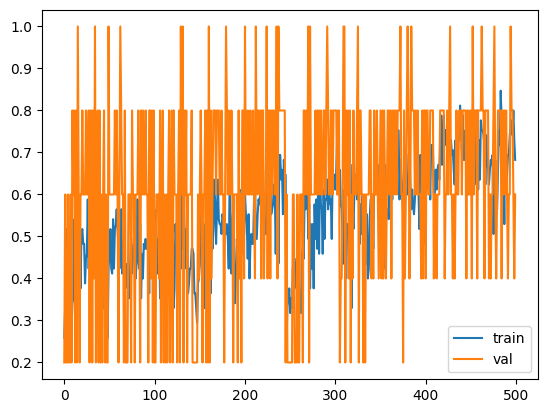

In [50]:
import matplotlib.pyplot as plt

plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.legend(['train','val'])
plt.show()

In [51]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - categorical_accuracy: 0.6000 - loss: 0.9687


[0.9686709642410278, 0.6000000238418579]

In [52]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape   ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ lstm_6 (LSTM)       │ (None, 30, 64) │ 442,112 │
├─────────────────────┼────────────────┼─────────┤
│ lstm_7 (LSTM)       │ (None, 30, 64) │  33,024 │
├─────────────────────┼────────────────┼─────────┤
│ lstm_8 (LSTM)       │ (None, 64)     │  33,024 │
├─────────────────────┼────────────────┼─────────┤
│ dense_6 (Dense)     │ (None, 64)     │   4,160 │
├─────────────────────┼────────────────┼─────────┤
│ dense_7 (Dense)     │ (None, 32)     │   2,080 │
├─────────────────────┼────────────────┼─────────┤
│ dense_8 (Dense)     │ (None, 3)      │      99 │
└─────────────────────┴────────────────┴─────────┘

 Total params: 1,543,499 (5.89 MB)

 Trainable params: 514,499 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,029,000 (3.93 MB)

In [53]:
res = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [64]:
actions[np.argmax(res[4])]

np.str_('hello')

In [65]:
actions[np.argmax(y_test[4])]

np.str_('iloveyou')

In [66]:
model.save('action.h5')

In [67]:
import os
print(os.getcwd())

C:\Users\GAURAV


In [68]:
import os

print(os.path.exists('action.h5'))

True


In [69]:
import os

print(os.path.abspath('action.h5'))

C:\Users\GAURAV\action.h5


TEST IN REAL TIME

In [70]:
from scipy import stats

In [71]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

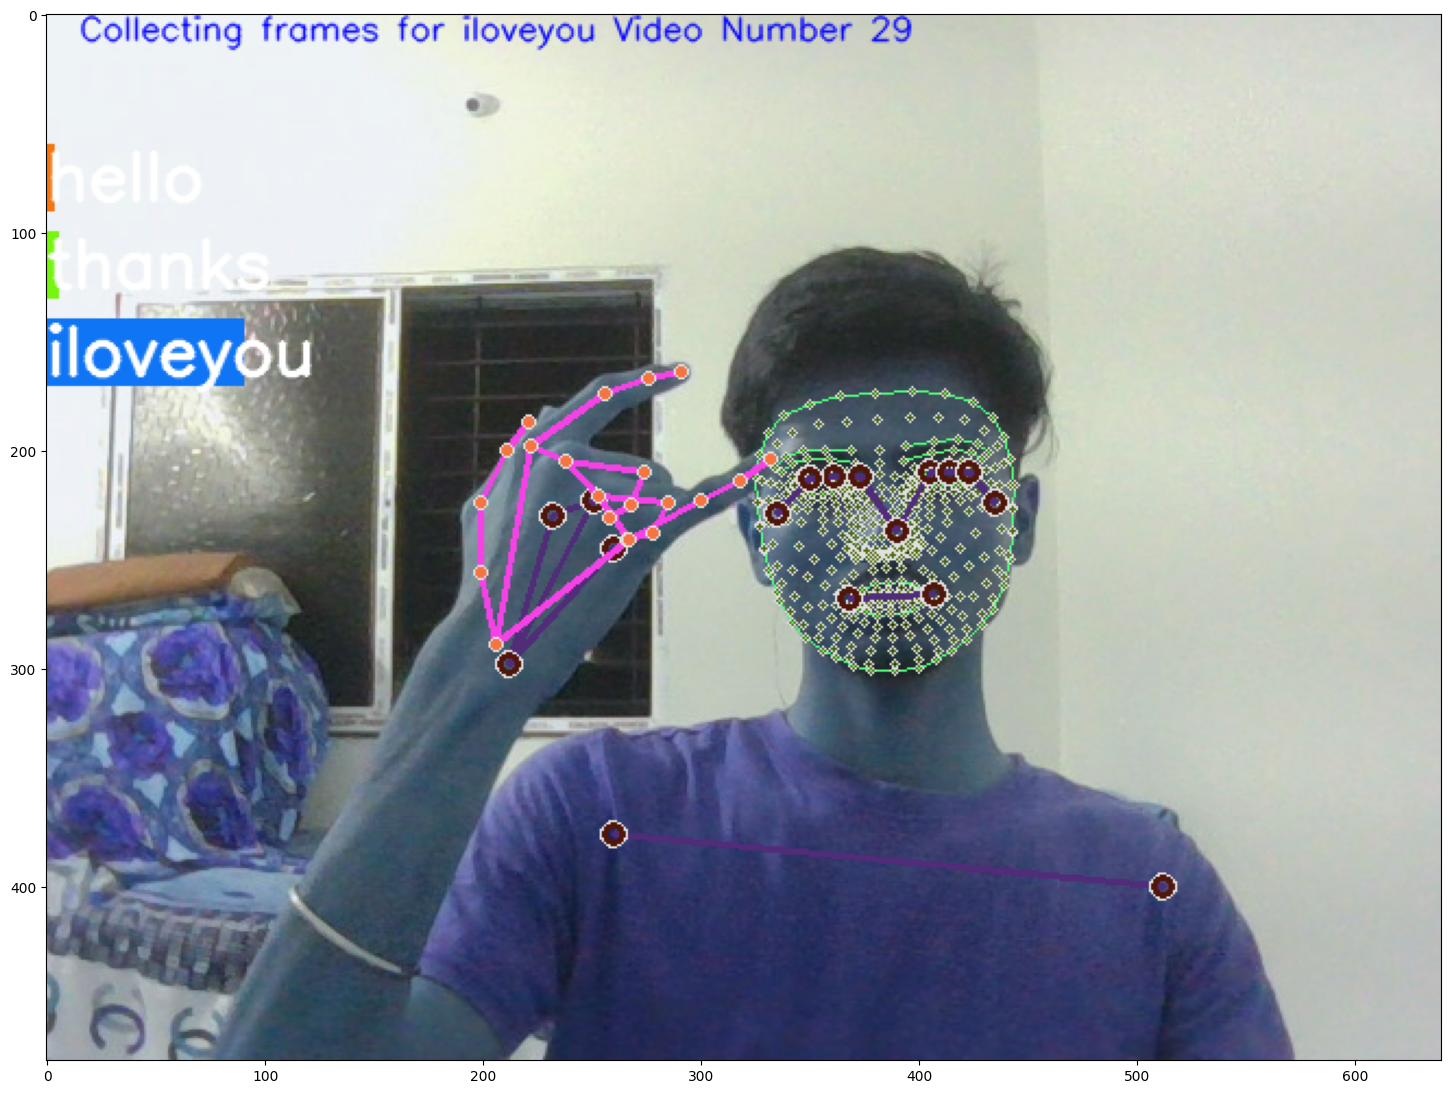

In [74]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res[0], actions, image, colors))
plt.show()

In [75]:
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti